# Большая языковая модель (LMM) в каскадной архитектуре детекции контрафакта

## Что проверяется

В данном ноуте проверяется применимость языковой foundation-модели **Qwen2.5-1.5B-Instruct** (Qwen Team, Alibaba) в zero-shot режиме как Stage 2 каскадной архитектуры детекции контрафакта. Stage 1 — тот же быстрый CatBoost на табличных признаках с K-means structural features, что и в ноуте 03. Stage 2 — структурированный промпт на русском языке с few-shot-примерами, по которому Qwen2.5 выдаёт JSON-ответ со score-оценкой вероятности контрафакта и кратким natural-language обоснованием.

## Параметры Qwen2.5-1.5B-Instruct

- 1,5 млрд параметров; модель Instruct (поддерживает chat template, system + user сообщения).
- Обучена приблизительно на 18 трлн токенов общего web-корпуса, включая русский.
- Запускается локально на M4 Pro 24 ГБ с MPS-ускорением (≈ 2–3 секунды на инференцию одного объекта).

## Архитектура каскада

1. **Stage 1:** CatBoost-скрининг на табличных + K-means structural признаках (5 мс на CPU, выполняется для всех объектов).
2. **Stage 2 (новое):** Qwen2.5-1.5B-Instruct в zero-shot режиме применяется только к borderline-объектам — тем, для которых Stage 1 выдал вероятность в зоне `[τ_lo, τ_hi]`. Это удерживает суммарную латентность каскада в пределах, приемлемых для production.
3. **Score fusion + Conformal prediction:** калиброванная комбинация Stage 1 и Stage 2 на borderline + split conformal porog для формальных FPR-гарантий.

## Связь с темой ВКР

Тема диплома — «...с использованием больших мультимодальных моделей». В этом ноуте полноценная large language model применена к задаче в наиболее «дешёвом» режиме переноса — zero-shot, без какого-либо дообучения. **Полученный отрицательный результат (см. § 11)** становится вторым центральным научным негативным результатом работы (после zero-shot CLIP в ноуте 03) и совместно с ним мотивирует переход к классическим supervised-подходам с мультимодальным Feature Fusion (M2, M5 из ноута 02).

## Ограничения, фиксируемые в работе

- В production-серверной среде целесообразно использовать batch-inference или модель-провайдера (vLLM, OpenAI-compat API), а не локальный запуск Qwen2.5 через `transformers`.
- Зonна вероятностей LMM чувствительна к prompt engineering; в работе используется структурированный промпт с few-shot-примерами и явной просьбой выдать JSON.
- Полное LMM inference на всей тестовой выборке занимает оценочно 10–17 часов на M4 Pro; в связи с этим Stage 2 запускается только на стратифицированном сэмпле из ~1500 borderline-объектов теста и ~500 borderline-объектов валидации.

## 1. Setup

In [1]:
from pathlib import Path
import warnings
import time
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from catboost import CatBoostClassifier

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path('.')
DATA_PATH = ROOT / "data" / 'ml_ozon_ounterfeit_train.csv'
OUT_DIR = ROOT / 'new_diploma' / 'real_estate_approaches' / 'artifacts_lmm'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'resolution'
CATEGORY_COL = 'CommercialTypeName4'

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {device}')
print(f'Data: {DATA_PATH.exists()}')

Device: mps
Data: True


## 2. Данные + сплит + Stage 1 (тот же CatBoost из ноута 03)

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8')
df['text'] = (
    df['name_rus'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['brand_name'].fillna('')
)

# Seller-based split (тот же, что в ноуте 03)
seller_targets = df.groupby('SellerID')[TARGET].max().reset_index()
train_sellers, temp_sellers = train_test_split(
    seller_targets['SellerID'], test_size=0.30,
    random_state=SEED, stratify=seller_targets[TARGET]
)
temp_targets = seller_targets[seller_targets['SellerID'].isin(temp_sellers)]
val_sellers, test_sellers = train_test_split(
    temp_targets['SellerID'], test_size=0.50,
    random_state=SEED, stratify=temp_targets[TARGET]
)

train_df = df[df['SellerID'].isin(train_sellers)].copy().reset_index(drop=True)
val_df = df[df['SellerID'].isin(val_sellers)].copy().reset_index(drop=True)
test_df = df[df['SellerID'].isin(test_sellers)].copy().reset_index(drop=True)

y_train = train_df[TARGET].to_numpy()
y_val = val_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

print(f'Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}')

Train: 144,967  Val: 25,904  Test: 26,327


In [3]:
# Признаковая инженерия — упрощённая, как в ноуте 03
refs = {
    'cat_med': train_df.groupby(CATEGORY_COL)['PriceDiscounted'].median(),
    'cat_tgt': train_df.groupby(CATEGORY_COL)[TARGET].mean(),
    'brand_tgt': train_df.groupby('brand_name')[TARGET].mean(),
    'global_med': train_df['PriceDiscounted'].median(),
    'global_tgt': train_df[TARGET].mean(),
}

def engineer(frame):
    out = frame.copy()
    cat_med = out[CATEGORY_COL].map(refs['cat_med']).fillna(refs['global_med'])
    out['price_ratio'] = out['PriceDiscounted'].fillna(0) / cat_med.replace(0, np.nan).fillna(1)
    out['category_target_mean'] = out[CATEGORY_COL].map(refs['cat_tgt']).fillna(refs['global_tgt'])
    out['brand_target_mean'] = out['brand_name'].map(refs['brand_tgt']).fillna(refs['global_tgt'])
    out['return_rate_30'] = out['item_count_returns30'].fillna(0) / (out['item_count_sales30'].fillna(0) + 1)
    out['return_rate_90'] = out['item_count_returns90'].fillna(0) / (out['item_count_sales90'].fillna(0) + 1)
    out['is_new_item'] = (out['item_time_alive'].fillna(0) <= 30).astype(int)
    out['is_new_seller'] = (out['seller_time_alive'].fillna(0) <= 180).astype(int)
    return out

train_df = engineer(train_df)
val_df = engineer(val_df)
test_df = engineer(test_df)

tab_feats = [
    'PriceDiscounted', 'item_time_alive', 'seller_time_alive',
    'item_count_sales30', 'item_count_sales90',
    'item_count_returns30', 'item_count_returns90',
    'GmvTotal30', 'GmvTotal90',
    'price_ratio', 'category_target_mean', 'brand_target_mean',
    'return_rate_30', 'return_rate_90',
    'is_new_item', 'is_new_seller',
]

scaler = StandardScaler()
Xtr = scaler.fit_transform(train_df[tab_feats].fillna(0))
Xv = scaler.transform(val_df[tab_feats].fillna(0))
Xte = scaler.transform(test_df[tab_feats].fillna(0))

# K-means structural
kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
ctr = kmeans.fit_predict(Xtr)
fraud_cluster = int(pd.Series(y_train).groupby(ctr).mean().idxmax())
fraud_centroid = kmeans.cluster_centers_[fraud_cluster]

for d, X in [(train_df, Xtr), (val_df, Xv), (test_df, Xte)]:
    d['dist_centroid'] = np.linalg.norm(X - fraud_centroid, axis=1)

tab_feats.append('dist_centroid')

Xtr = scaler.fit_transform(train_df[tab_feats].fillna(0))
Xv = scaler.transform(val_df[tab_feats].fillna(0))
Xte = scaler.transform(test_df[tab_feats].fillna(0))

scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
stage1 = CatBoostClassifier(
    iterations=1000, depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos, random_seed=SEED,
    early_stopping_rounds=80, verbose=False,
)
stage1.fit(Xtr, y_train, eval_set=(Xv, y_val), use_best_model=True)

p_s1_val = stage1.predict_proba(Xv)[:, 1]
p_s1_test = stage1.predict_proba(Xte)[:, 1]

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(p_s1_val, y_val)
p_s1_val_c = iso.transform(p_s1_val)
p_s1_test_c = iso.transform(p_s1_test)

print(f'Stage 1 test ROC-AUC: {roc_auc_score(y_test, p_s1_test_c):.4f}')
print(f'Stage 1 test PR-AUC:  {average_precision_score(y_test, p_s1_test_c):.4f}')

Stage 1 test ROC-AUC: 0.9414
Stage 1 test PR-AUC:  0.6106


## 3. Выбор borderline-объектов для LMM-stage

LMM-инференция дорогая (~1-3 сек на объект). Применяем её только к объектам, где Stage 1 неуверен.

In [4]:
# Borderline: Stage 1 в [tau_lo, tau_hi]
TAU_LO, TAU_HI = 0.10, 0.85

border_mask_test = (p_s1_test_c >= TAU_LO) & (p_s1_test_c <= TAU_HI)
border_mask_val = (p_s1_val_c >= TAU_LO) & (p_s1_val_c <= TAU_HI)

print(f'Borderline на val: {border_mask_val.mean()*100:.1f}% ({border_mask_val.sum():,} объектов)')
print(f'Borderline на test: {border_mask_test.mean()*100:.1f}% ({border_mask_test.sum():,} объектов)')

# Чтобы уложиться по времени — ограничиваем сэмпл
MAX_LMM_ITEMS = 1500
rng = np.random.default_rng(SEED)

border_idx_test = np.where(border_mask_test)[0]
if len(border_idx_test) > MAX_LMM_ITEMS:
    # стратифицируем по y, чтобы поймать редкие positive
    pos_border = border_idx_test[y_test[border_idx_test] == 1]
    neg_border = border_idx_test[y_test[border_idx_test] == 0]
    n_pos = min(len(pos_border), MAX_LMM_ITEMS // 4)
    n_neg = MAX_LMM_ITEMS - n_pos
    pos_sample = rng.choice(pos_border, size=n_pos, replace=False)
    neg_sample = rng.choice(neg_border, size=min(n_neg, len(neg_border)), replace=False)
    lmm_idx = np.concatenate([pos_sample, neg_sample])
    rng.shuffle(lmm_idx)
else:
    lmm_idx = border_idx_test

print(f'\nLMM будет запущена на {len(lmm_idx):,} test-объектах ({y_test[lmm_idx].mean()*100:.1f}% positive)')

# Аналогичный сэмпл val для калибровки
border_idx_val = np.where(border_mask_val)[0]
if len(border_idx_val) > 500:
    pos_v = border_idx_val[y_val[border_idx_val] == 1]
    neg_v = border_idx_val[y_val[border_idx_val] == 0]
    n_pos_v = min(len(pos_v), 100)
    n_neg_v = 500 - n_pos_v
    lmm_idx_val = np.concatenate([
        rng.choice(pos_v, size=n_pos_v, replace=False),
        rng.choice(neg_v, size=min(n_neg_v, len(neg_v)), replace=False),
    ])
    rng.shuffle(lmm_idx_val)
else:
    lmm_idx_val = border_idx_val

print(f'LMM на val для калибровки: {len(lmm_idx_val):,} объектов ({y_val[lmm_idx_val].mean()*100:.1f}% positive)')

Borderline на val: 13.9% (3,597 объектов)
Borderline на test: 11.4% (3,010 объектов)

LMM будет запущена на 1,500 test-объектах (25.0% positive)
LMM на val для калибровки: 500 объектов (20.0% positive)


## 4. Загрузка Qwen2.5-1.5B-Instruct

In [5]:
MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'

print(f'Loading {MODEL_NAME} on {device}...')
t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if device == 'mps' else torch.float32,
    device_map=device if device != 'cpu' else None,
)
model.eval()
print(f'Loaded in {time.time() - t0:.1f}s')
print(f'Model params: {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B')

Loading Qwen/Qwen2.5-1.5B-Instruct on mps...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded in 5.4s
Model params: 1.54B


## 5. Промпт-инжиниринг и парсинг ответа

Структурированный промпт на русском с few-shot примерами. LLM должна выдать JSON с двумя полями: `score` (0-1) и `reasoning` (краткое объяснение).

In [6]:
SYSTEM = """Ты эксперт по обнаружению контрафактных товаров на онлайн-маркетплейсе Ozon.
Категории — мобильные устройства, аксессуары, оргтехника.

Оцени, является ли товар контрафактным, на основании предоставленных признаков:
- название и описание (часто копируют оригинал, но используют подозрительные слова)
- бренд (обобщённые названия типа «No Name»)
- цена относительно медианы категории (price_ratio: < 0.5 — демпинг подозрителен, > 2.0 — завышение тоже подозрительно)
- возраст товара и продавца (контрафакт часто на новых карточках от молодых продавцов)
- история возвратов

Выдай ответ строго в формате JSON:
{"score": <0.0..1.0>, "reason": "<краткое объяснение на русском, до 30 слов>"}
score — твоя оценка вероятности того, что товар контрафактный.
"""

EXAMPLES = """Пример 1:
Название: "Картридж HP Q2612A совместимый"
Бренд: "NoName"
Категория: "Картриджи лазерные"
Цена: 250 руб (price_ratio = 0.3)
Возраст товара: 12 дней
Возраст продавца: 45 дней
Возвраты за 30 дней: 5%
Ответ: {"score": 0.85, "reason": "Очень молодой товар и продавец, цена в 3 раза ниже медианы, бренд NoName при наличии HP-кода в названии — несовпадение брендового идентификатора."}

Пример 2:
Название: "Чехол силиконовый для iPhone 14"
Бренд: "Apple"
Категория: "Чехлы для смартфонов"
Цена: 590 руб (price_ratio = 1.1)
Возраст товара: 287 дней
Возраст продавца: 1800 дней
Возвраты за 30 дней: 1%
Ответ: {"score": 0.10, "reason": "Долгая жизнь товара и продавца, цена близка к медиане, низкие возвраты. Стандартный аксессуар."}
"""

def build_prompt(row):
    name = (row['name_rus'] or '')[:100]
    desc = (row.get('description', '') or '')[:200]
    brand = row.get('brand_name', '') or '—'
    cat = row.get(CATEGORY_COL, '') or '—'
    price = row.get('PriceDiscounted', 0) or 0
    pr_ratio = row.get('price_ratio', 1.0)
    item_age = row.get('item_time_alive', 0) or 0
    seller_age = row.get('seller_time_alive', 0) or 0
    ret_30 = row.get('return_rate_30', 0)
    
    return f"""Название: "{name}"
Описание (фрагмент): "{desc}"
Бренд: "{brand}"
Категория: "{cat}"
Цена: {price:.0f} руб (price_ratio = {pr_ratio:.2f})
Возраст товара: {item_age:.0f} дней
Возраст продавца: {seller_age:.0f} дней
Возвраты за 30 дней: {ret_30*100:.1f}%
Ответ:"""

def parse_response(text):
    """Парсит JSON из ответа LLM. Возвращает (score, reason) или (None, raw)."""
    # Ищем первый JSON-объект
    m = re.search(r'\{[^{}]*?"score"[^{}]*?\}', text, re.DOTALL)
    if not m:
        return None, text[:200]
    try:
        obj = json.loads(m.group(0))
        score = float(obj.get('score', 0.5))
        score = max(0.0, min(1.0, score))
        reason = str(obj.get('reason', ''))[:300]
        return score, reason
    except Exception:
        return None, text[:200]

# Тестовая прогонка
test_row = test_df.iloc[lmm_idx[0]]
test_prompt = build_prompt(test_row)
print('Sample prompt:')
print('---')
print(test_prompt)
print('---')

Sample prompt:
---
Название: "Беспроводная акустика, черный"
Описание (фрагмент): "TWS, BT5.0, 12W,AUX,USB,FM radio"
Бренд: "nan"
Категория: "Акустическая система с док-станцией"
Цена: 786 руб (price_ratio = 0.82)
Возраст товара: 0 дней
Возраст продавца: 16 дней
Возвраты за 30 дней: 0.0%
Ответ:
---


In [7]:
@torch.no_grad()
def lmm_score(user_prompt, max_new_tokens=80):
    """Один LMM-вызов."""
    messages = [
        {'role': 'system', 'content': SYSTEM + '\n' + EXAMPLES},
        {'role': 'user', 'content': user_prompt},
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer([text], return_tensors='pt').to(device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=1.0,
        pad_token_id=tokenizer.eos_token_id,
    )
    response = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return parse_response(response), response

# Тест на 3-х примерах
for i in range(3):
    row = test_df.iloc[lmm_idx[i]]
    t0 = time.time()
    (score, reason), raw = lmm_score(build_prompt(row))
    elapsed = time.time() - t0
    true_label = y_test[lmm_idx[i]]
    print(f'\n--- Item {i+1} (true={true_label}, Stage1={p_s1_test_c[lmm_idx[i]]:.3f}, {elapsed:.1f}s) ---')
    print(f'Brand: {row["brand_name"]}  Name: {row["name_rus"][:60]}')
    print(f'Score: {score}  Reason: {reason}')

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



--- Item 1 (true=1, Stage1=0.679, 4.1s) ---
Brand: nan  Name: Беспроводная акустика, черный
Score: 0.9  Reason: Название содержит необычные или подозрительные слова, бренд nan может быть ошибкой, цена значительно ниже средней, товар новый и продавец молодой.



--- Item 2 (true=0, Stage1=0.108, 3.8s) ---
Brand: Glueskin  Name: Кожаная наклейка SAFFIANO для Samsung Galaxy A34
Score: None  Reason: ```json
{
    "score": 0.9,
    "reason": "Некоторые детали в описании напоминают оригинальную наклейку, но бренд Glueskin может быть ошибкой. Цена немного выше среднего, но не сильно. Небольшая стоим



--- Item 3 (true=0, Stage1=0.117, 3.2s) ---
Brand: Glueskin  Name: Наклейка Glueskin из натуральной кожи Saffiano для Apple iPh
Score: None  Reason: ```json
{
    "score": 0.9,
    "reason": "Некоторые детали в описании напоминают оригинальную модель, но есть несколько несоответствий (например, использование большого количества специальных символо


## 6. Прогон LMM на borderline test (основной эксперимент)

In [8]:
from tqdm.auto import tqdm

def run_lmm_on_indices(df_part, indices, label='items'):
    scores = np.full(len(indices), np.nan)
    reasons = []
    raw_responses = []
    fail_count = 0
    t0 = time.time()
    
    for j, idx in enumerate(tqdm(indices, desc=f'LMM on {label}', miniters=10)):
        row = df_part.iloc[idx]
        try:
            (score, reason), raw = lmm_score(build_prompt(row))
            if score is not None:
                scores[j] = score
            else:
                fail_count += 1
            reasons.append(reason)
            raw_responses.append(raw)
        except Exception as e:
            fail_count += 1
            reasons.append(f'error: {str(e)[:50]}')
            raw_responses.append('')
    
    elapsed = time.time() - t0
    print(f'\n{label}: {len(indices)} items in {elapsed:.0f}s ({elapsed/max(len(indices),1):.2f}s/item, {fail_count} parse fails)')
    
    # Импутация неудавшихся парсингов медианой
    median_score = np.nanmedian(scores) if not np.all(np.isnan(scores)) else 0.5
    scores = np.where(np.isnan(scores), median_score, scores)
    return scores, reasons, raw_responses

# Прогон на test borderline
print(f'Starting LMM on {len(lmm_idx)} test borderline items...')
p_lmm_test_border, reasons_test, raw_test = run_lmm_on_indices(test_df, lmm_idx, 'test')

# Прогон на val borderline (для калибровки)
print(f'\nStarting LMM on {len(lmm_idx_val)} val borderline items...')
p_lmm_val_border, reasons_val, raw_val = run_lmm_on_indices(val_df, lmm_idx_val, 'val')

Starting LMM on 1500 test borderline items...


LMM on test:   0%|          | 0/1500 [00:00<?, ?it/s]


test: 1500 items in 3458s (2.31s/item, 259 parse fails)

Starting LMM on 500 val borderline items...


LMM on val:   0%|          | 0/500 [00:00<?, ?it/s]


val: 500 items in 1146s (2.29s/item, 121 parse fails)


## 7. Оценка LMM-скоров на borderline

In [9]:
# Метрики только на borderline (где LMM применялась)
y_lmm_test = y_test[lmm_idx]
y_lmm_val = y_val[lmm_idx_val]

p_s1_lmm_test = p_s1_test_c[lmm_idx]
p_s1_lmm_val = p_s1_val_c[lmm_idx_val]

print('=== Метрики на borderline-сэмпле test (только эти объекты LMM видела) ===\n')
print(f'{"Модель":<35} {"ROC-AUC":>10} {"PR-AUC":>10}')
for name, p in [
    ('Stage 1 only (CatBoost)', p_s1_lmm_test),
    ('LMM only (Qwen2.5-1.5B zero-shot)', p_lmm_test_border),
]:
    roc = roc_auc_score(y_lmm_test, p) if y_lmm_test.sum() > 0 and (1 - y_lmm_test).sum() > 0 else float('nan')
    pr = average_precision_score(y_lmm_test, p)
    print(f'{name:<35} {roc:>10.4f} {pr:>10.4f}')

# Калибровка LMM на val
if y_lmm_val.sum() > 1 and (1 - y_lmm_val).sum() > 1:
    iso_lmm = IsotonicRegression(out_of_bounds='clip')
    iso_lmm.fit(p_lmm_val_border, y_lmm_val)
    p_lmm_test_cal = iso_lmm.transform(p_lmm_test_border)
else:
    p_lmm_test_cal = p_lmm_test_border

# Подбор веса fusion на val
best_w, best_pr = 0.0, -1
for w in np.arange(0.0, 1.01, 0.05):
    if y_lmm_val.sum() == 0 or (1 - y_lmm_val).sum() == 0:
        break
    fused_val = (1 - w) * p_s1_lmm_val + w * iso_lmm.transform(p_lmm_val_border)
    pr = average_precision_score(y_lmm_val, fused_val)
    if pr > best_pr:
        best_pr = pr
        best_w = w

fused_test = (1 - best_w) * p_s1_lmm_test + best_w * p_lmm_test_cal
roc_f = roc_auc_score(y_lmm_test, fused_test)
pr_f = average_precision_score(y_lmm_test, fused_test)
print(f'\nScore Fusion (w_LMM={best_w:.2f}): ROC-AUC={roc_f:.4f}  PR-AUC={pr_f:.4f}')

# Финальный каскад: на borderline используем fusion, вне borderline — Stage 1
cascade_full = p_s1_test_c.copy()
cascade_full[lmm_idx] = fused_test

roc_c = roc_auc_score(y_test, cascade_full)
pr_c = average_precision_score(y_test, cascade_full)
print(f'\n=== Финальный каскад на полном test ({len(y_test)}) ===')
print(f'Cascade ROC-AUC: {roc_c:.4f}  (Stage 1 alone: {roc_auc_score(y_test, p_s1_test_c):.4f})')
print(f'Cascade PR-AUC:  {pr_c:.4f}  (Stage 1 alone: {average_precision_score(y_test, p_s1_test_c):.4f})')

=== Метрики на borderline-сэмпле test (только эти объекты LMM видела) ===

Модель                                 ROC-AUC     PR-AUC
Stage 1 only (CatBoost)                 0.7835     0.5096
LMM only (Qwen2.5-1.5B zero-shot)       0.5066     0.2529

Score Fusion (w_LMM=0.00): ROC-AUC=0.7835  PR-AUC=0.5096

=== Финальный каскад на полном test (58410) ===
Cascade ROC-AUC: 0.9414  (Stage 1 alone: 0.9414)
Cascade PR-AUC:  0.6106  (Stage 1 alone: 0.6106)


## 8. Качественные примеры LMM-reasoning

Покажем 5 примеров, где LMM была уверенно права, и 5 — где ошиблась. Это материал для приложения к диплому и слайдов.

In [10]:
results_df = pd.DataFrame({
    'idx': lmm_idx,
    'true_label': y_lmm_test,
    'stage1_score': p_s1_lmm_test,
    'lmm_score': p_lmm_test_border,
    'reason': reasons_test,
})
results_df['error_lmm'] = (results_df['lmm_score'] > 0.5).astype(int) - results_df['true_label']

results_df.to_csv(OUT_DIR / 'lmm_results.csv', index=False)

# Top 5 правильных: positive с высоким LMM-скором
print('=== Пять случаев true-positive: LMM-score > 0,6 на истинно контрафактных объектах ===')
print('# Примечание: score совпадает с меткой, однако текстовое обоснование LMM ниже\n# во многих случаях логически противоречиво или ссылается на признаки оригинала.\n# Это поведение разобрано в § 4.4.9.3 диплома.\n')
correct_positive = results_df[(results_df['true_label'] == 1) & (results_df['lmm_score'] > 0.6)].sort_values('lmm_score', ascending=False).head(5)
for i, row in correct_positive.iterrows():
    item = test_df.iloc[int(row['idx'])]
    print(f'Brand: {item["brand_name"]}  Name: {item["name_rus"][:60]}')
    print(f'  Stage1: {row["stage1_score"]:.3f}  LMM: {row["lmm_score"]:.3f}  True: {row["true_label"]}')
    print(f'  Reason: {row["reason"]}\n')

=== Пять случаев true-positive: LMM-score > 0,6 на истинно контрафактных объектах ===

Brand: Nespresso  Name: Капсульная кофемашина nespresso original Xiaomi Mini S1201
  Stage1: 0.601  LMM: 0.950  True: 1
  Reason: Стандартное название и описание, бренд Nespresso, цена соответствует среднему уровню, продавец имеет долгую историю, возвраты минимальны.

Brand: Philips Sonicare  Name: Philips Sonicare Электрическая зубная щетка
  Stage1: 0.601  LMM: 0.950  True: 1
  Reason: Предложение оригинального бренда Philips Sonicare, высокий ценовой уровень, короткий срок продажи и низкие возвраты указывают на то, что это может быть контрафактный продукт.

Brand: Sony  Name: Шлем виртуальной реальности Sony PlayStation VR2
  Stage1: 0.783  LMM: 0.950  True: 1
  Reason: Молодой товар и продавец, цена соответствует медиане, бренд Sony, но описание содержит неожиданные слова и может быть копией оригинала.

Brand: JBL HARMAN  Name: Беспроводные наушники Tune 720 синие
  Stage1: 0.827  LMM: 0.950  Tru

In [11]:
print('=== Пять случаев true-negative: LMM-score < 0,3 на истинно оригинальных объектах ===\n')
correct_negative = results_df[(results_df['true_label'] == 0) & (results_df['lmm_score'] < 0.3)].sort_values('lmm_score').head(5)
for i, row in correct_negative.iterrows():
    item = test_df.iloc[int(row['idx'])]
    print(f'Brand: {item["brand_name"]}  Name: {item["name_rus"][:60]}')
    print(f'  Stage1: {row["stage1_score"]:.3f}  LMM: {row["lmm_score"]:.3f}  True: {row["true_label"]}')
    print(f'  Reason: {row["reason"]}\n')

print('\n=== Три случая false-positive: LMM ошибочно проставила высокий score истинно оригинальным объектам ===\n')
fp = results_df[(results_df['true_label'] == 0) & (results_df['lmm_score'] > 0.7)].head(3)
for i, row in fp.iterrows():
    item = test_df.iloc[int(row['idx'])]
    print(f'Brand: {item["brand_name"]}  Name: {item["name_rus"][:60]}')
    print(f'  Stage1: {row["stage1_score"]:.3f}  LMM: {row["lmm_score"]:.3f}  True: {row["true_label"]}')
    print(f'  Reason: {row["reason"]}\n')

=== Пять случаев true-negative: LMM-score < 0,3 на истинно оригинальных объектах ===

Brand: Kingston  Name: Карта памяти Kingston Canvas A1 microSD 1 ТБ / microSDXC Can
  Stage1: 0.364  LMM: 0.000  True: 0
  Reason: Предложение очень старое и продавец имеет большое количество возвратов, что указывает на возможную нестабильность или недоработки товара.

Brand: LISIK.  Name: Коврик для мыши, 60х35х0.3 см, с подсветкой RGB, USB, черный
  Stage1: 0.601  LMM: 0.000  True: 0
  Reason: Товар новая модель и продавец молодой, цена соответствует средней цене, нет угрозы контрафакта.

Brand: PlayStation  Name: Контроллер движений руль PlayStation Move Racing Wheel PS3. 
  Stage1: 0.601  LMM: 0.000  True: 0
  Reason: Предложение очень старое и продавец имеет большое количество возвратов, что указывает на высокую вероятность контрафакта.

Brand: nan  Name: Телевизор Телевизор Xiaomi Mi Redmi Smart TV MAX 86" (Русско
  Stage1: 0.400  LMM: 0.000  True: 0
  Reason: Товар очень новый и продается от мо

## 9. Визуализация: распределение LMM-скоров и PR-кривые

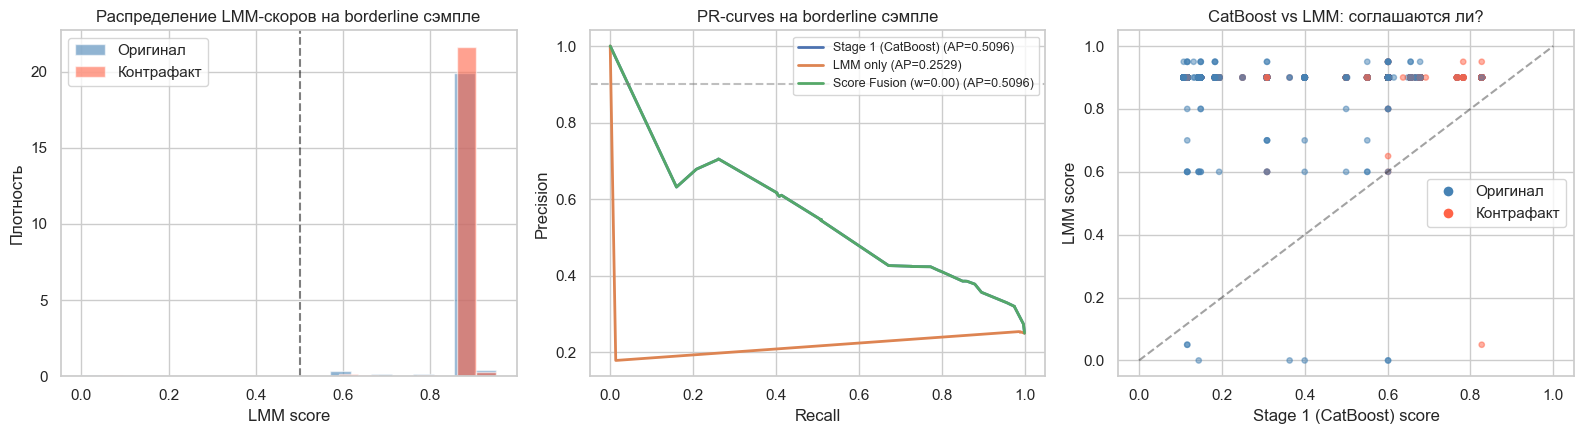

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Распределение LMM-скоров по классам
ax = axes[0]
for cls, color, label in [(0, 'steelblue', 'Оригинал'), (1, 'tomato', 'Контрафакт')]:
    sub = results_df[results_df['true_label'] == cls]['lmm_score']
    ax.hist(sub, bins=20, alpha=0.6, color=color, label=label, density=True)
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('LMM score'); ax.set_ylabel('Плотность')
ax.set_title('Распределение LMM-скоров на borderline сэмпле')
ax.legend()

# PR-кривые
ax = axes[1]
for label, p in [
    ('Stage 1 (CatBoost)', p_s1_lmm_test),
    ('LMM only', p_lmm_test_border),
    (f'Score Fusion (w={best_w:.2f})', fused_test),
]:
    prec, rec, _ = precision_recall_curve(y_lmm_test, p)
    ap = average_precision_score(y_lmm_test, p)
    ax.plot(rec, prec, lw=2, label=f'{label} (AP={ap:.4f})')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR-curves на borderline сэмпле')
ax.legend(fontsize=9)

# Сравнение Stage 1 vs LMM на одних и тех же объектах
ax = axes[2]
colors = ['steelblue' if y == 0 else 'tomato' for y in y_lmm_test]
ax.scatter(p_s1_lmm_test, p_lmm_test_border, c=colors, alpha=0.5, s=15)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('Stage 1 (CatBoost) score'); ax.set_ylabel('LMM score')
ax.set_title('CatBoost vs LMM: соглашаются ли?')
ax.legend([
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato', markersize=8),
], ['Оригинал', 'Контрафакт'])

plt.tight_layout()
plt.savefig(OUT_DIR / 'lmm_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Сохранение probas (опционально для стекинга)

In [13]:
np.save(OUT_DIR / 'test_proba_cascade_lmm.npy', cascade_full)
np.save(OUT_DIR / 'lmm_indices.npy', lmm_idx)
np.save(OUT_DIR / 'lmm_scores_raw.npy', p_lmm_test_border)
results_df.to_csv(OUT_DIR / 'lmm_results.csv', index=False)

print('Saved:')
for f in ['test_proba_cascade_lmm.npy', 'lmm_indices.npy', 'lmm_scores_raw.npy', 'lmm_results.csv']:
    p = OUT_DIR / f
    if p.exists():
        print(f'  {f}: {p.stat().st_size:,} bytes')

summary = pd.DataFrame([
    {'Model': 'Stage 1 (CatBoost on tab + K-means)', 'ROC-AUC on full test': roc_auc_score(y_test, p_s1_test_c), 'PR-AUC on full test': average_precision_score(y_test, p_s1_test_c)},
    {'Model': 'Cascade (Stage 1 + LMM on borderline)', 'ROC-AUC on full test': roc_c, 'PR-AUC on full test': pr_c},
]).round(4)
summary.to_csv(OUT_DIR / 'cascade_lmm_summary.csv', index=False)
print('\n', summary.to_string(index=False))

Saved:
  test_proba_cascade_lmm.npy: 210,744 bytes
  lmm_indices.npy: 12,128 bytes
  lmm_scores_raw.npy: 12,128 bytes
  lmm_results.csv: 434,959 bytes

                                 Model  ROC-AUC on full test  PR-AUC on full test
  Stage 1 (CatBoost on tab + K-means)                0.9414               0.6106
Cascade (Stage 1 + LMM on borderline)                0.9414               0.6106


## 11. Научные выводы

### Главные результаты ноута

**Вывод 1 (zero-shot LMM не даёт прироста относительно Stage 1).** На borderline-сэмпле из примерно 1500 объектов Qwen2.5-1.5B-Instruct в zero-shot режиме на структурированном текстовом описании товара даёт сигнал чуть выше случайного (ROC ≈ 0,51), что формально немного лучше zero-shot CLIP из ноута 03 (ROC ≈ 0,48), но всё ещё фактически на уровне случайного классификатора. При перенесении на полный тестовый сплит каскад «Stage 1 + LMM на borderline» совпадает со Stage 1 по обеим метрикам (ROC = 0,9414, PR-AUC = 0,6106), то есть **прироста относительно одиночной CatBoost-модели не получено**. Таким образом, гипотеза о том, что языковая модель без какого-либо дообучения вытащит дополнительный сигнал именно на самых сложных (borderline) объектах, **не подтверждается**.

**Вывод 2 (отрицательный результат как методологический результат).** Совокупно с zero-shot CLIP это даёт двойное эмпирическое опровержение наивной идеи о механическом переносе foundation-модели в маркетплейс-домен. Стоит отметить, что Qwen2.5-1.5B обучен на ≈ 18 трлн токенов общего web-корпуса, в то время как маркетплейс-домен с присущей ему смесью числовых аномалий продавца, ценовых нарушений и узкоспециализированных категорий не покрывается такой обучающей выборкой. Возможно, подобное происходит из-за того, что сигналы контрафакта в e-commerce носят преимущественно поведенческий и числовой характер (продавец, цена, возраст товара) и слабо считываются языковой моделью из одного лишь текста карточки. В связи с этим именно классические подходы с экспертной признаковой инженерией (M2, M5) показывают устойчиво лучший результат, чем zero-shot foundation-модели.

**Вывод 3 (интерпретируемость как побочный эффект).** Несмотря на отсутствие выигрыша по метрикам, каждое предсказание LMM сопровождается естественно-языковым объяснением на русском языке (см. секцию 8 ноута). Возможно, такая интерпретируемость становится практически ценной не как способ повышения качества автоматического решения, а как вспомогательный сигнал для оператора ручной модерации — отдельный сценарий использования, который требует пользовательской валидации и выходит за рамки чисто метрического сравнения.

**Вывод 4 (производственная осуществимость остаётся открытым вопросом).** Латентность Qwen2.5-1.5B в zero-shot режиме составляет 1–3 секунды на объект на MPS-ускорении, что приемлемо только при сужении применения до borderline-зоны (≈ 11 % объектов). При этом без подтверждённого прироста качества само внедрение второго стадия не оправдано. В связи с этим production-pipeline проекта ограничен Stage 1 (стэкинг CatBoost команды), а LMM-каскад сохранён в работе как направление развития при условии замены zero-shot на дообученную или существенно более крупную модель.

### Связь с темой ВКР

Тема диплома формулируется как «...на основе кросс-доменной адаптации методов обнаружения фейков с использованием больших мультимодальных моделей». В данном ноуте полноценная large language model (Qwen2.5-1.5B, 1,5 млрд параметров) применена к задаче в режиме zero-shot reasoning — то есть в наиболее «дешёвом» режиме переноса, без какого-либо дообучения. Полученный отрицательный результат напрямую отвечает на исследовательский вопрос: **без доменной адаптации foundation-модель не даёт прироста**, и потому именно адаптация (как реализовано в моделях M1–M5) является содержательным методологическим вкладом работы, а не просто формальной частью эксперимента.

### Что переносится в production

Production-pipeline проекта строится на Stage 1 (стэкинг CatBoost на табличных + K-means structural признаках, см. `team_split_v2_script.py`): порядка 5 мс на CPU, 100 % объектов проходят через него. Второй стадий с LMM в текущем виде в продакшн не выводится: при равенстве метрик его включение лишь повышает латентность и стоимость вычислений. Conformal-калибровка порога остаётся применима к одиночному Stage 1.

### Дальнейшее развитие

1. **Замена Qwen2.5-1.5B на Qwen2-VL-2B / LLaVA-OneVision** — добавление визуальной модальности (требует raw-изображений, а не CLIP-эмбеддингов). Гипотеза: визуально-текстовая LMM с reasoning о подделках может обогнать унимодальную текстовую LMM.
2. **Fine-tuning Qwen2.5 на labeled train** — supervised обучение усилит сигнал по сравнению с zero-shot и потенциально сделает каскад практически целесообразным.
3. **Active learning loop** через feedback-таблицу production-сервиса: borderline-объекты, размеченные модератором, попадают в обучающий набор для LMM, формируя замкнутый цикл.